In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### 1.Data Cleaning and Preparation:

In [3]:
# Load dataset and read the dataset

df = pd.read_csv('Cardiotocographic.csv')
print(df.shape)
print('='*50)
print(df.info())

(2126, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2105 non-null   float64
 1   AC        2106 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2105 non-null   float64
 6   DP        2105 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2105 non-null   float64
 11  Width     2105 non-null   float64
 12  Tendency  2105 non-null   float64
 13  NSP       2105 non-null   float64
dtypes: float64(14)
memory usage: 232.7 KB
None


In [6]:
# handling missing values

# check the missing value

print(df.isnull().sum())

# fill the missing values with median value 
print('*'*50)
clean_data = df.fillna(df.median())

print(clean_data.isnull().sum())

LB          21
AC          20
FM           0
UC           0
DL           0
DS          21
DP          21
ASTV         0
MSTV         0
ALTV         0
MLTV        21
Width       21
Tendency    21
NSP         21
dtype: int64
**************************************************
LB          0
AC          0
FM          0
UC          0
DL          0
DS          0
DP          0
ASTV        0
MSTV        0
ALTV        0
MLTV        0
Width       0
Tendency    0
NSP         0
dtype: int64


In [7]:
# identify and corret any inconsistencies in datatypes


# check datatypes all columns

print(df.dtypes)

# all columns are numerical datatypes,because no datatype conversion or correction was required

LB          float64
AC          float64
FM          float64
UC          float64
DL          float64
DS          float64
DP          float64
ASTV        float64
MSTV        float64
ALTV        float64
MLTV        float64
Width       float64
Tendency    float64
NSP         float64
dtype: object


In [8]:
print(type(clean_data))

<class 'pandas.core.frame.DataFrame'>


In [9]:
# Detect and treat outliers if necessary

Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR

upper_bound = Q3 + 1.5 * IQR

outliers = ((df < lower_bound) | (df > upper_bound))

print(outliers.sum())
print('*'*50)
df2 = clean_data.clip(lower_bound,upper_bound,axis = 1)
print(df2.head())

LB           10
AC           40
FM          347
UC           13
DL          125
DS          120
DP          284
ASTV         10
MSTV         80
ALTV        318
MLTV         81
Width        10
Tendency     10
NSP         559
dtype: int64
**************************************************
           LB        AC   FM        UC        DL   DS   DP  ASTV  MSTV  ALTV  \
0  120.000000  0.000000  0.0  0.000000  0.000000  0.0  0.0  73.0   0.5  27.5   
1  132.000000  0.006380  0.0  0.006380  0.003190  0.0  0.0  17.0   2.1   0.0   
2  133.000000  0.003322  0.0  0.008306  0.003322  0.0  0.0  16.0   2.1   0.0   
3  134.000000  0.002561  0.0  0.007742  0.002561  0.0  0.0  16.0   2.4   0.0   
4  131.948232  0.006515  0.0  0.008143  0.000000  0.0  0.0  16.0   2.4   0.0   

    MLTV  Width  Tendency  NSP  
0   2.40   64.0  0.999926  1.0  
1  10.40  130.0  0.000000  1.0  
2  13.40  130.0  0.000000  1.0  
3  20.35  117.0  1.000000  1.0  
4  19.90  117.0  1.000000  1.0  


### 2.Statistical Summary:

In [10]:
# statistical summary for each variable in the dataset


df.describe()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
count,2105.000000,2106.000000,2126.000000,2126.000000,2126.000000,2105.000000,2105.000000,2126.000000,2126.000000,2126.000000,2105.000000,2105.000000,2105.000000,2105.000000
mean,133.343598,0.003219,0.009894,0.004391,0.001895,0.000003,0.000175,46.995984,1.364378,10.285964,8.284887,70.429260,0.316371,1.304507
std,11.270154,0.004391,0.067540,0.003340,0.003343,0.000142,0.000840,18.813973,1.173632,21.205041,7.772858,42.931822,0.645622,0.644619
min,51.842487,-0.019284,-0.480634,-0.014925,-0.015393,-0.001353,-0.005348,-63.000000,-6.600000,-91.000000,-50.700000,-174.000000,-3.000000,-1.025988
25%,126.000000,0.000000,0.000000,0.001851,0.000000,0.000000,0.000000,32.000000,0.700000,0.000000,4.600000,37.000000,0.000000,1.000000
50%,133.000000,0.001634,0.000000,0.004484,0.000000,0.000000,0.000000,49.000000,1.200000,0.000000,7.400000,67.000000,0.000000,1.000000
75%,140.000000,0.005650,0.002567,0.006536,0.003289,0.000000,0.000000,61.000000,1.700000,11.000000,10.900000,100.000000,1.000000,1.000000
max,214.000000,0.038567,0.961268,0.030002,0.030769,0.002706,0.010695,162.000000,13.800000,182.000000,101.400000,357.000000,3.000000,5.000000


the statistical summary is calculated after missing-value treatment and outlier treatment, 
which is appropriate for the data-cleaning/preparation workflow.

### 3.Data Visualization:

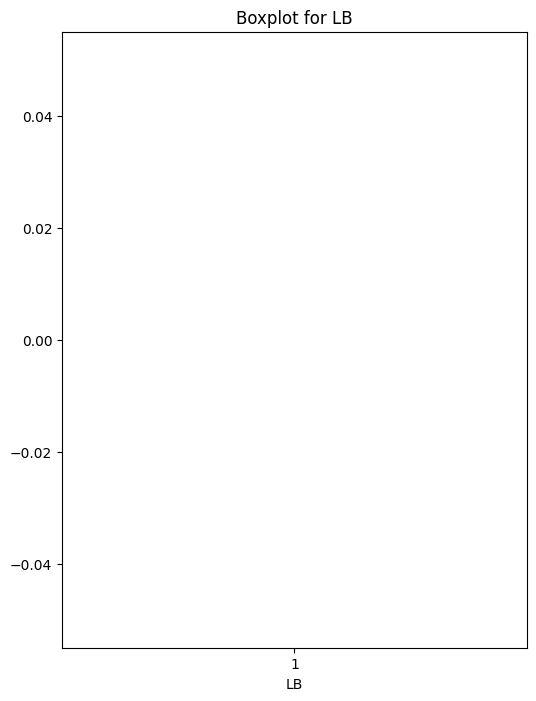

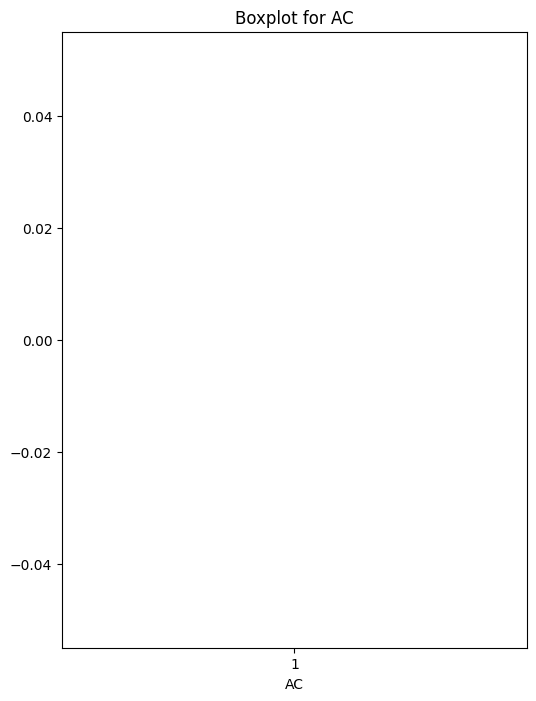

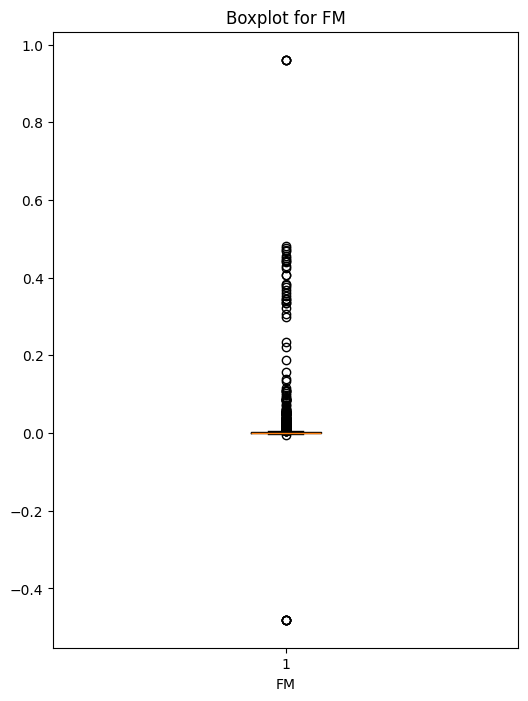

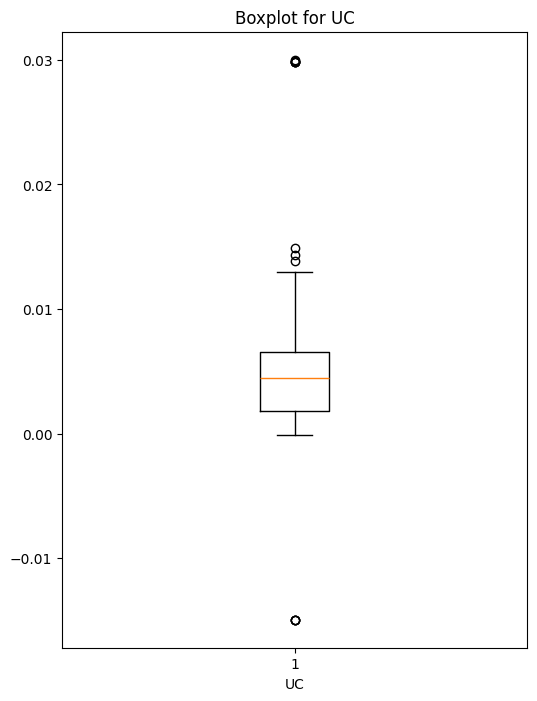

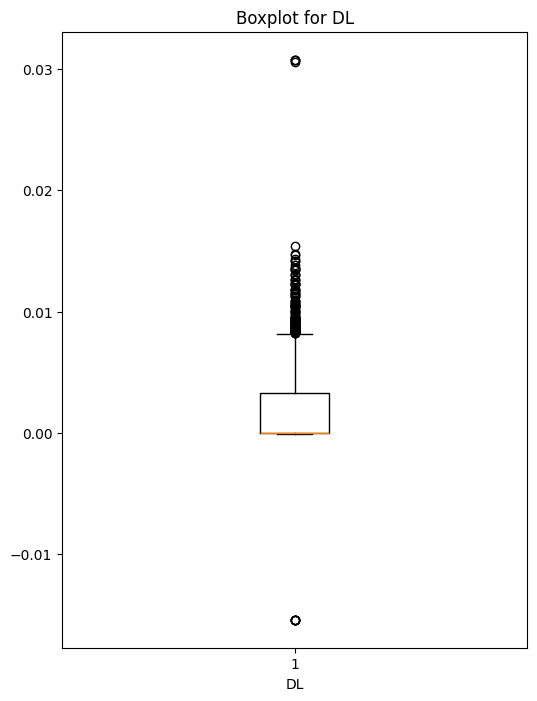

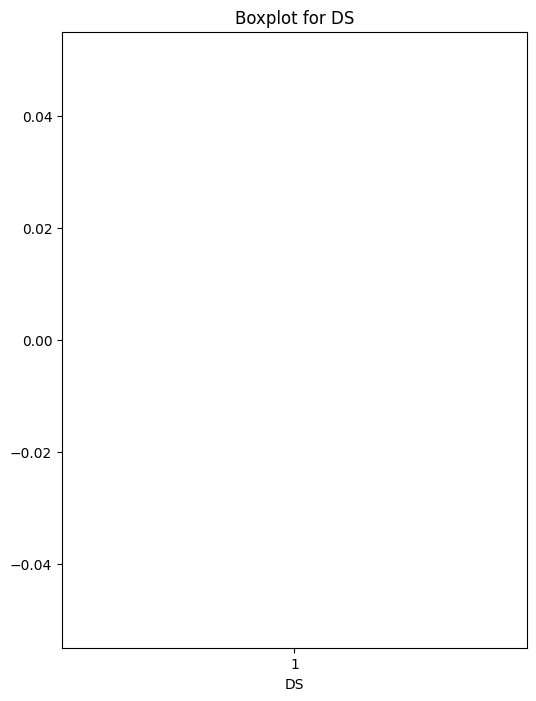

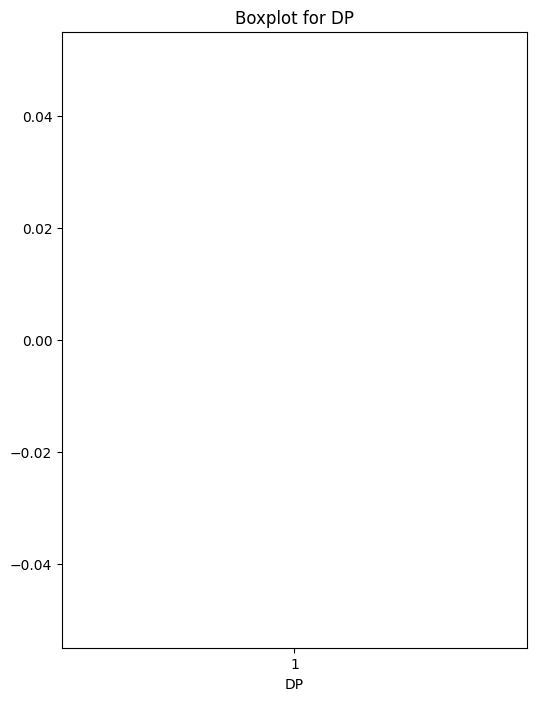

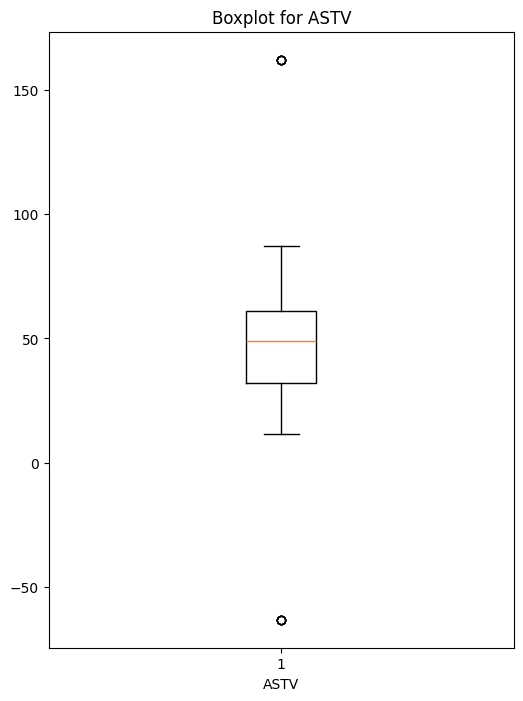

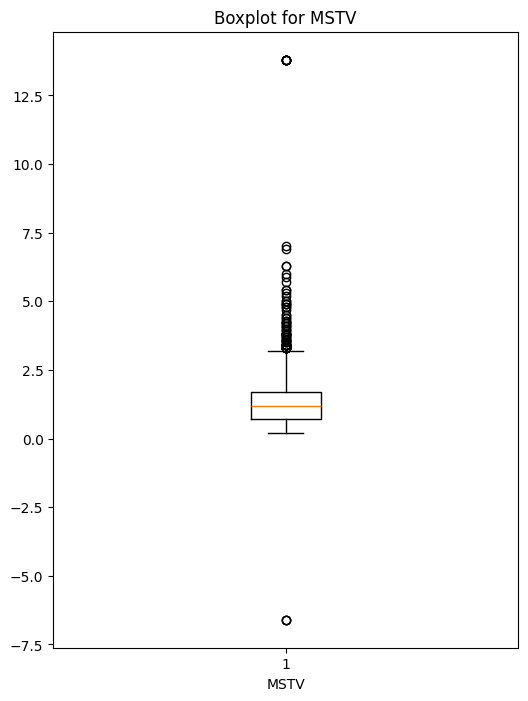

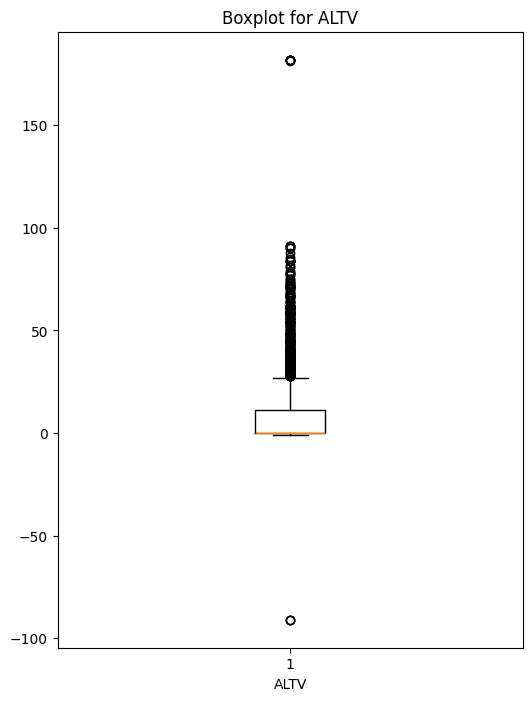

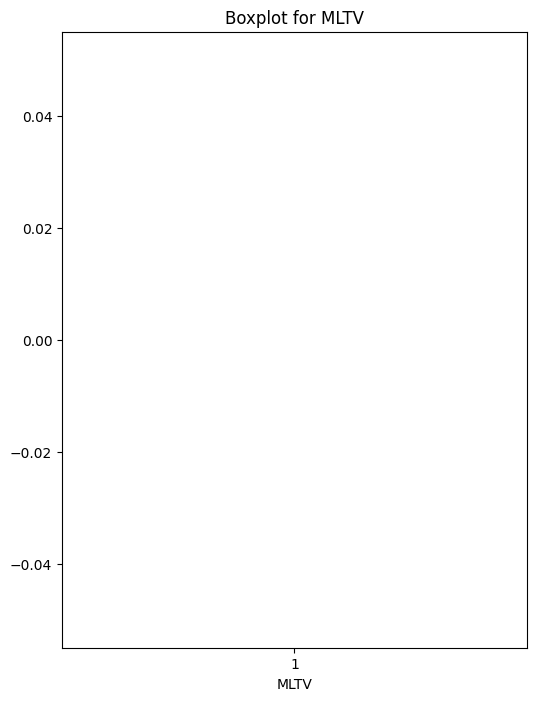

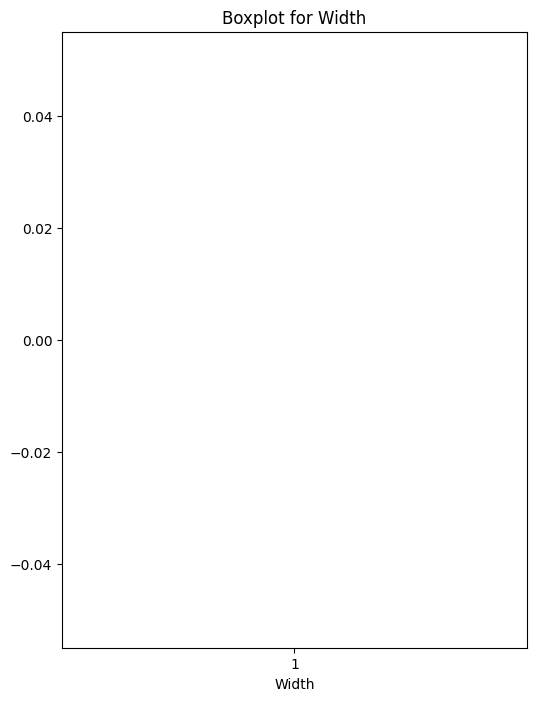

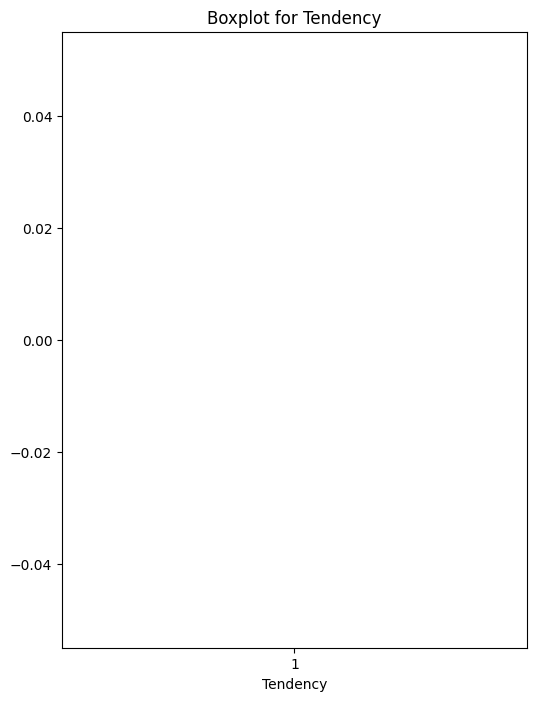

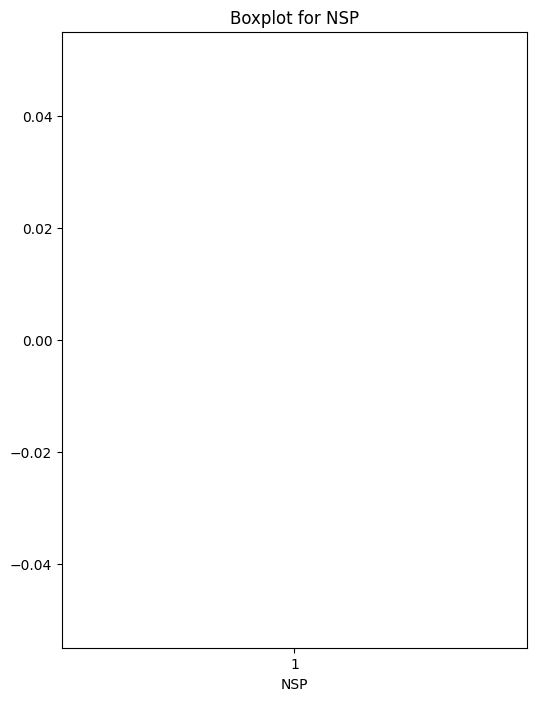

In [11]:
# create histogram or boxplots to visualize the distributions of various numerical variables.

import matplotlib.pyplot as plt
for col in df.columns:
    plt.figure(figsize = (6,8))
    plt.boxplot(df[col])
    plt.title(f"Boxplot for {col}")
    plt.xlabel(col)
    plt.show()

In [16]:
# Use bar charts or pie charts to display the frequency of categories for categorical Variables.

# for the dataset,all columns are numerical.there are no categorical variables available for creating bar charts or pie charts.

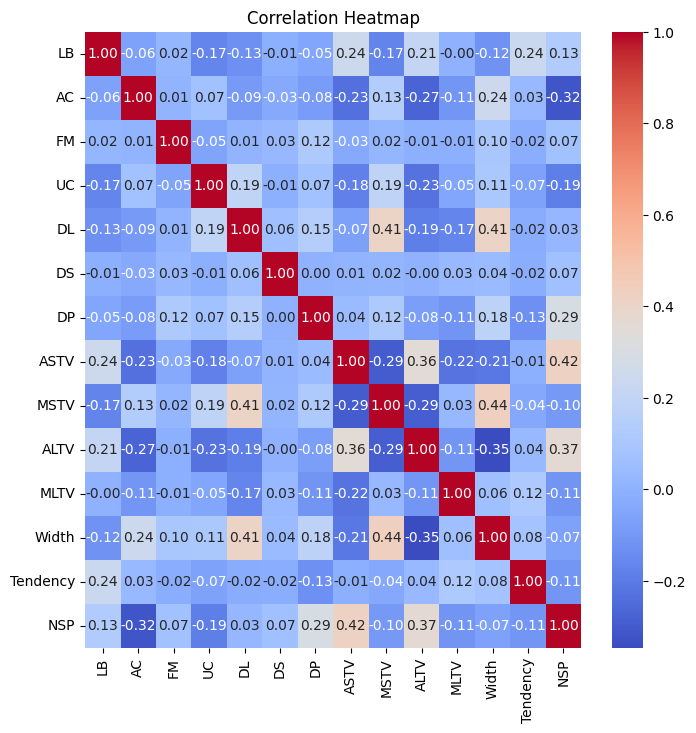

In [12]:
# Generate scatter plots or correlation heatmaps to explore relationships between pairs of variables.
import seaborn as sns

plt.figure(figsize = (8,8))
corr_matrix = df.corr()

sns.heatmap(corr_matrix,annot = True,cmap = 'coolwarm',fmt = '.2f')
plt.title('Correlation Heatmap')
plt.show()

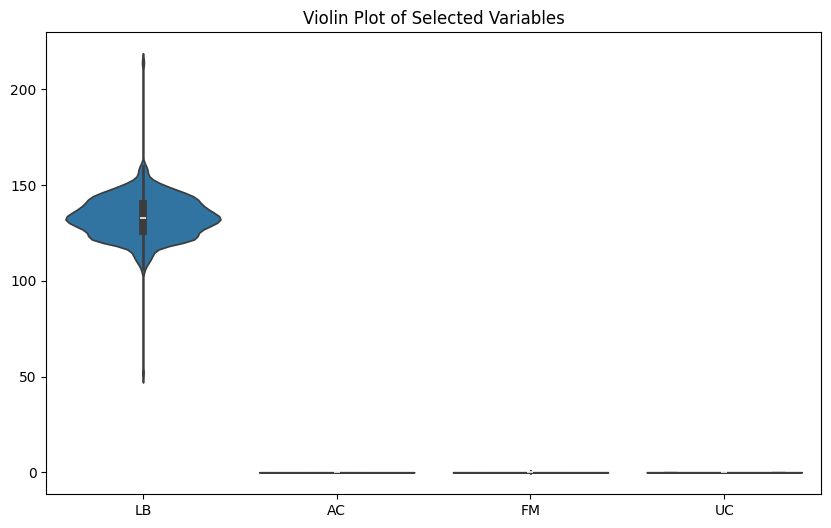

In [17]:
plt.figure(figsize=(10,6))

sns.violinplot(data=df[['LB', 'AC', 'FM', 'UC']])

plt.title('Violin Plot of Selected Variables')
plt.show()

### 4.Pattern Recognition and Insights:

In [19]:
# Identify any correlations between variables and discuss their potential implications.

corr_matrix = df.corr()
print(corr_matrix)

print('*'*50)
#Look for trends or patterns over time if temporal data is available.

print(df.columns)

# the dataset does not contains any temporal variables

                LB        AC        FM        UC        DL        DS  \
LB        1.000000 -0.063830  0.018777 -0.166570 -0.126959 -0.005438   
AC       -0.063830  1.000000  0.009433  0.072012 -0.093507 -0.033623   
FM        0.018777  0.009433  1.000000 -0.053226  0.009718  0.029901   
UC       -0.166570  0.072012 -0.053226  1.000000  0.190128 -0.006937   
DL       -0.126959 -0.093507  0.009718  0.190128  1.000000  0.058625   
DS       -0.005438 -0.033623  0.029901 -0.006937  0.058625  1.000000   
DP       -0.047724 -0.084590  0.121284  0.070658  0.145425  0.004285   
ASTV      0.242625 -0.231103 -0.032691 -0.181161 -0.069361  0.008452   
MSTV     -0.170473  0.134168  0.017055  0.189406  0.410102  0.016163   
ALTV      0.210728 -0.271390 -0.011936 -0.227304 -0.186967 -0.004398   
MLTV     -0.003457 -0.106529 -0.006237 -0.049460 -0.165750  0.034349   
Width    -0.118425  0.238436  0.097213  0.107397  0.410031  0.040832   
Tendency  0.236864  0.032481 -0.018339 -0.066610 -0.023569 -0.01

### 5.Conclusion:

# summarize the key insights and pattern discovered through your exploratory analysis
The exploratory analysis successfully identified data quality issues, variable distributions, outliers, and relationships among features.
        These findings provide a strong foundation for building accurate predictive models and support data-driven decision-making in fetal health assessment.
            The insights gained from EDA will guide subsequent preprocessing, feature engineering, and machine learning stages of the project.